In [9]:
import time
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
from xThreat import xThreat

In [11]:
data_path = './1-data-preparation/data-storage/xThreat_data_v3.parquet'
df_events = pd.read_parquet(data_path, engine='fastparquet')

df_events['shot'] = ~df_events['shot_outcome'].isna()
df_events['goal'] = df_events['shot_outcome'] == 'Goal'

df_events.drop(columns=['id', 'shot_outcome', 'possession'], inplace=True)
df_size_bytes = df_events.memory_usage(deep=True).sum()
df_size_mb = df_size_bytes / (1024 ** 2)  # Convert to MB
print(f"DataFrame size: {df_size_mb:.2f} MB")

DataFrame size: 1039.54 MB


In [12]:
# df_events.to_parquet('temp.parquet')

In [13]:
n_x = 16
n_y = 12
xT_filters = xThreat(n_x, n_y)

In [14]:
df_events.describe()

,x,y,possession_length,chain_length,match_id,period,player_id,shot_statsbomb_xg,under_pressure,next_x,next_y,next_under_pressure,next_team_id,next_player_id
count,3.985659e+06,3.985659e+06,3.985659e+06,3.985659e+06,3.985659e+06,3.985659e+06,3.985659e+06,28860.000000,1022517.0,3.985659e+06,3.985659e+06,1022851.0,3.985659e+06,3.985659e+06
mean,5.132544e+01,3.383289e+01,1.023497e+01,6.102686e+00,3.033199e+06,1.490277e+00,1.589834e+04,0.114731,1.0,5.133620e+01,3.383240e+01,1.0,2.426442e+02,1.589749e+04
std,2.319977e+01,1.937700e+01,1.144458e+01,7.992756e+00,1.533470e+06,4.999055e-01,4.423549e+04,0.149185,0.0,2.320754e+01,1.937926e+01,0.0,3.277420e+02,4.423339e+04
min,8.750000e-02,8.500000e-02,0.000000e+00,0.000000e+00,9.575000e+03,1.000000e+00,2.935000e+03,0.000180,1.0,8.750000e-02,8.500000e-02,1.0,1.000000e+00,2.935000e+03
25%,3.482500e+01,1.700000e+01,3.000000e+00,1.000000e+00,3.754016e+06,1.000000e+00,4.884000e+03,0.030111,1.0,3.482500e+01,1.700000e+01,1.0,1.370000e+02,4.884000e+03
50%,5.057500e+01,3.374500e+01,7.000000e+00,3.000000e+00,3.825792e+06,1.000000e+00,6.849000e+03,0.059229,1.0,5.057500e+01,3.374500e+01,1.0,2.120000e+02,6.849000e+03
75%,6.833750e+01,5.066000e+01,1.400000e+01,8.000000e+00,3.879862e+06,2.000000e+00,1.262600e+04,0.125978,1.0,6.833750e+01,5.066000e+01,1.0,2.210000e+02,1.262600e+04
max,1.049125e+02,6.791500e+01,2.300000e+02,1.540000e+02,3.901263e+06,2.000000e+00,4.264250e+05,0.992819,1.0,1.049125e+02,6.791500e+01,1.0,2.736000e+03,4.264250e+05


In [15]:
mask_current_state = (df_events['x'] < xT_filters.x_lims[1]) & (df_events['y'] < xT_filters.y_lims[1]) & (df_events['x'] >= xT_filters.x_lims[0]) & (df_events['y'] >= xT_filters.y_lims[0])
mask_next_state = (df_events['possession_kept'] == False) | (df_events['shot'] == True) | ((df_events['next_x'] < xT_filters.x_lims[1]) & (df_events['next_y'] < xT_filters.y_lims[1]) & (df_events['next_x'] >= xT_filters.x_lims[0]) & (df_events['next_y'] >= xT_filters.y_lims[0]))
print(mask_current_state.sum(), mask_next_state.sum(), (mask_current_state & mask_next_state).sum(), df_events.shape[0])

3985659 3985659 3985659 3985659


In [16]:
df_events[df_events['next_x'].isna()]

,x,y,possession_kept,possession_length,chain_length,previous_deleted,match_id,period,player_id,type,...,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id,shot,goal
index,,,,,,,,,,,,,,,,,,,,,


In [17]:
print(df_events[['x', 'y', 'next_x', 'next_y']].isna().sum())

x         0
y         0
next_x    0
next_y    0
dtype: int64


In [18]:
xT_filters.y_lims

(0, 68)

In [19]:
np.sum(((df_events['next_x'] < xT_filters.x_lims[1]) & (df_events['next_y'] < xT_filters.y_lims[1]) & (df_events['next_x'] >= xT_filters.x_lims[0]) & (df_events['next_y'] >= xT_filters.y_lims[0])))

np.int64(3985659)

In [20]:
n_x = 64
n_y = 48

In [21]:
xT_traditional = xThreat(n_x, n_y)
xT_traditional.fit(df_events)

In [23]:
df_events.columns.tolist()

['x',
 'y',
 'possession_kept',
 'possession_length',
 'chain_length',
 'previous_deleted',
 'match_id',
 'period',
 'player_id',
 'type',
 'shot_statsbomb_xg',
 'pass_height',
 'under_pressure',
 'next_type',
 'next_x',
 'next_y',
 'next_under_pressure',
 'next_team_id',
 'next_player_id',
 'shot',
 'goal',
 'x_state',
 'next_x_state',
 'y_state',
 'next_y_state',
 'state',
 'next_state']

In [25]:
xT_sb_xg = xThreat(n_x, n_y)
xT_sb_xg.fit(df_events, xG_column='shot_statsbomb_xg')

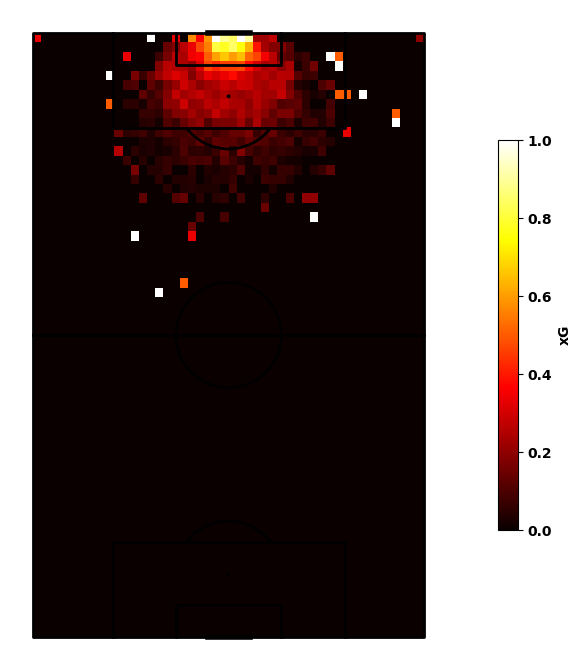

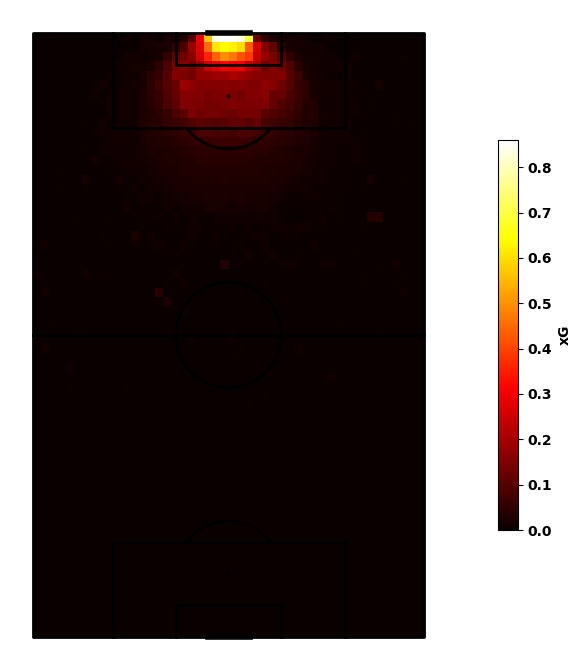

In [26]:
xT_traditional.plot_xG()
xT_sb_xg.plot_xG()

c:\Users\kwvanarem\Documents\Onderzoek\xthreat-error-quantification\.venv\Lib\site-packages\scipy\stats\_binned_statistic.py:694: RuntimeWarning: All-NaN slice encountered
  stat = stat_func(np.array(bin_map[i]))


(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x254944d3590>)

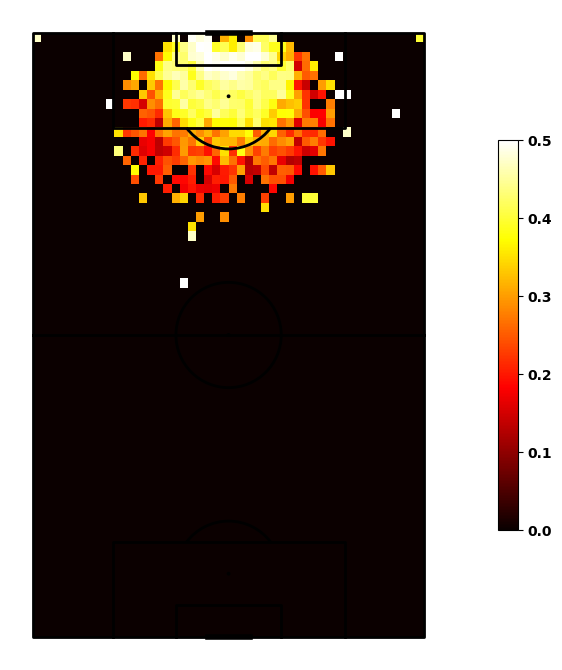

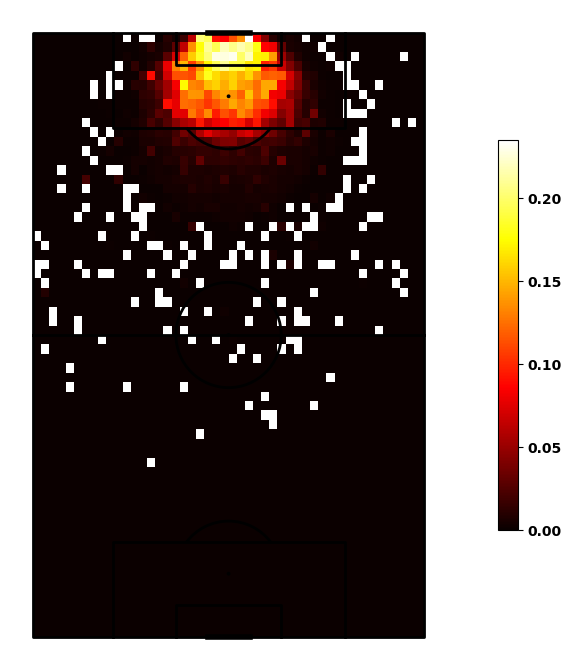

In [27]:
xT_traditional.plot_pitch_heatmap(xT_traditional.xG_std)
xT_sb_xg.plot_pitch_heatmap(xT_sb_xg.xG_std)

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x25499338b90>)

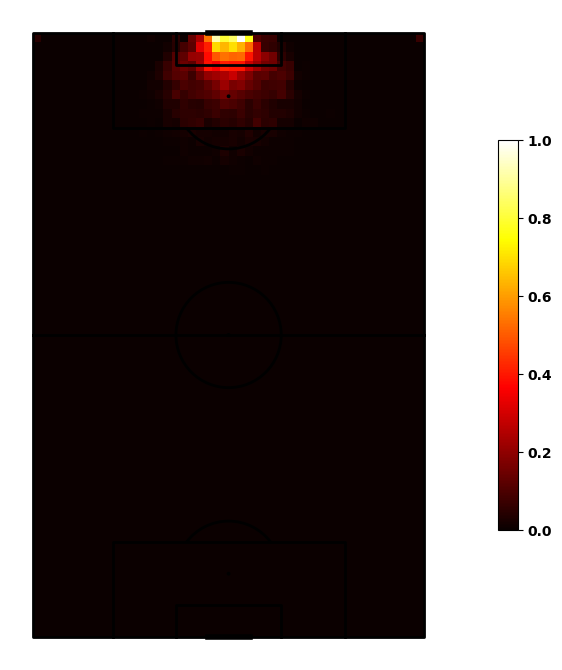

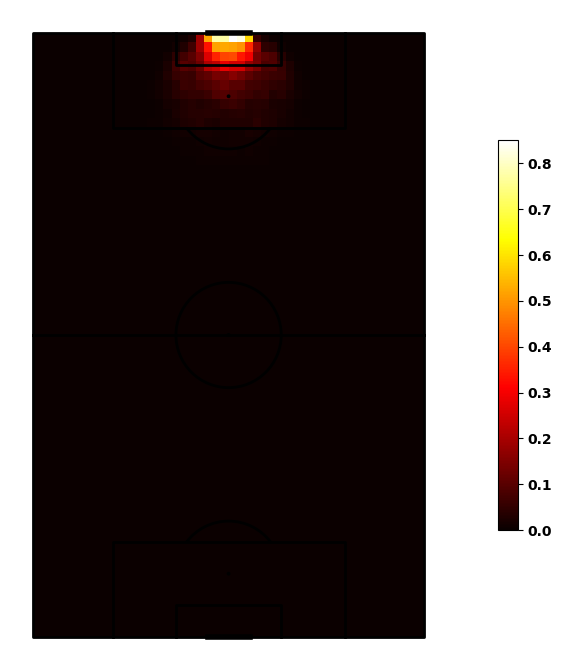

In [28]:
xT_traditional.plot_pitch_heatmap(xT_traditional.xG*xT_traditional.probability_shooting)
xT_sb_xg.plot_pitch_heatmap(xT_sb_xg.xG*xT_sb_xg.probability_shooting)

In [20]:
n_y

48

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x1e5fa01b7a0>)

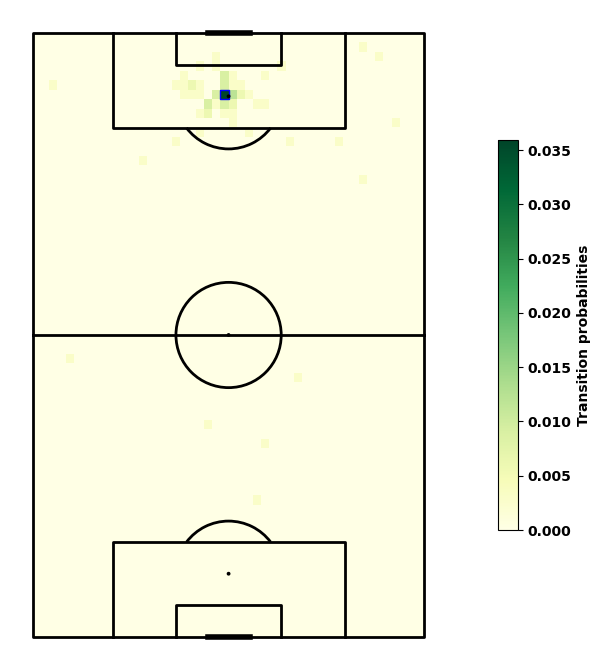

In [21]:
xT_traditional.plot_transitions_outgoing(57, 24)

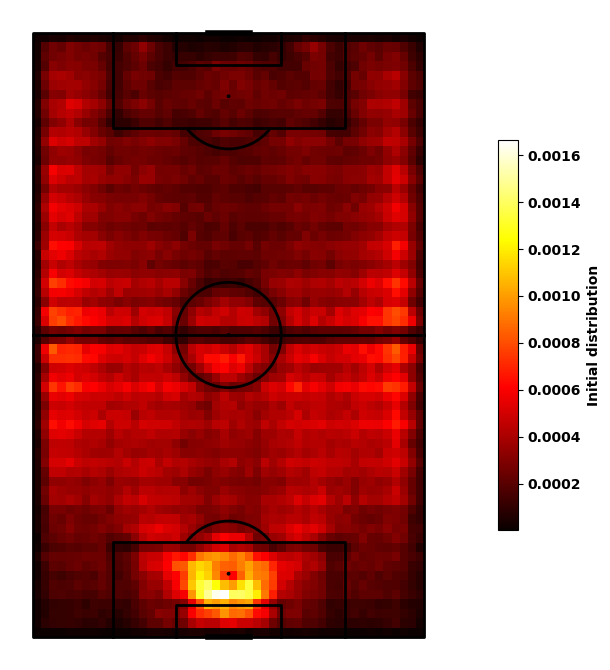

In [22]:
xT_traditional.plot_beginning_distribution()